# Data Conversion

## Libs

In [2]:
import os
import kagglehub
import json
from tqdm import tqdm
import shutil
from pathlib import Path
from collections import Counter
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

## Dowload the dataset
[26 Class Object detection dataset](https://www.kaggle.com/datasets/mohamedgobara/26-class-object-detection-dataset/data)

In [ ]:
# Download latest version
path = kagglehub.dataset_download('mohamedgobara/26-class-object-detection-dataset')

print('Path to dataset files:', path)

## Reorganizing Dataset (Converting from COCO To YOLO)

### Searching for json files
- Train folder

In [3]:
base_path = Path('~/.cache/kagglehub/datasets/mohamedgobara/26-class-object-detection-dataset/versions/1/Senior-Design-VIAD-4/').expanduser()

In [4]:
train_image_src =  base_path / 'train'

# List all JSON files
json_files = [f for f in os.listdir(train_image_src) if f.endswith('.json')]

if json_files:
    print('JSON files found:')
    for f in json_files:
        print(os.path.join(train_image_src, f))
else:
    print('No JSON files in this folder')

JSON files found:
/home/otonielnn/.cache/kagglehub/datasets/mohamedgobara/26-class-object-detection-dataset/versions/1/Senior-Design-VIAD-4/train/_annotations.coco.json


- Valid folder

In [5]:
val_image_src =  base_path / 'valid'

# List all JSON files
json_files = [f for f in os.listdir(val_image_src) if f.endswith('.json')]

if json_files:
    print('JSON files found:')
    for f in json_files:
        print(os.path.join(val_image_src, f))
else:
    print('No JSON files in this folder')

JSON files found:
/home/otonielnn/.cache/kagglehub/datasets/mohamedgobara/26-class-object-detection-dataset/versions/1/Senior-Design-VIAD-4/valid/_annotations.coco.json


- Test folder

In [6]:
test_image_src = base_path / 'test'
# List all JSON files
json_files = [f for f in os.listdir(test_image_src) if f.endswith('.json')]

if json_files:
    print('JSON files found:')
    for f in json_files:
        print(os.path.join(test_image_src, f))
else:
    print('No JSON files in this folder')

JSON files found:
/home/otonielnn/.cache/kagglehub/datasets/mohamedgobara/26-class-object-detection-dataset/versions/1/Senior-Design-VIAD-4/test/_annotations.coco.json


### Path variables to folders and json files

In [7]:
train_json = os.path.join(train_image_src, '_annotations.coco.json')
val_json = os.path.join(val_image_src, '_annotations.coco.json')
test_json = os.path.join(test_image_src, '_annotations.coco.json')

In [9]:
dataset_path = Path('~/.cache/kagglehub/datasets/uav-edge-intelligence/').expanduser()

train_image_dst = dataset_path / 'images/train'
val_image_dst = dataset_path / 'images/val'
test_image_dst = dataset_path / 'images/test'

train_label_dst = dataset_path / 'labels/train'
val_label_dst = dataset_path / 'labels/val'
test_label_dst = dataset_path / 'labels/test'

# Create destionation folders
for d in [train_image_dst, val_image_dst, test_image_dst, train_label_dst, val_label_dst, test_label_dst]:
    os.makedirs(d, exist_ok=True)

This is the most important part of the script. `COCO` and `YOLO` fundamentally disagree on how to draw a box around an object.

- `COCO Format`: Uses absolute pixels based on the top-left corner. (e.g., "Start at pixel 100, 50, draw a box 200 pixels wide and 300 pixels tall").

- `YOLO Format`: Uses percentages (from 0.0 to 1.0) based on the center point of the object. (The center of the box is at 50% of the image width and 40% of the image height)

To convert from COCO to YOLO, the code calculates the center point and then divides by the total image dimensions to get percentages:

$$ x_{center\_normalized} = \frac{x_{top\_left} + \frac{width}{2}}{image\_width} \\
y_{center\_normalized} = \frac{y_{top\_left} + \frac{height}{2}}{image\_height} \\
width_{normalized} = \frac{width}{image\_width} \\
height_{normalized} = \frac{height}{image\_height} $$

In [10]:
def coco_to_yolo_bbox(bbox, img_w, img_h):
    x, y, w, h = bbox
    x_c = (x + w/2) / img_w
    y_c = (y + h/2) / img_h
    return [x_c, y_c, w/img_w, h/img_h]

### Converting bbox from COCO to YOLO
- Read the JSON of coco and get the sizes and if of each Image
- Copies the image to the new dataset folder
- Creates the `.txt` file for the label
- Writes the on the `.txt` label file.

In [40]:
def convert_coco(json_path, image_src, image_dst, label_dst):
    with open(json_path) as f:
        data = json.load(f)

    id_to_file = {img['id']: img['file_name'] for img in data['images']}
    id_to_size = {img['id']: (img['width'], img['height']) for img in data['images']}
    all_image_ids = [img['id'] for img in data['images']]

    # Process all images with tqdm progress bar
    for img_id in tqdm(all_image_ids, desc=f'Processing {os.path.basename(json_path)}'):
        img_file = id_to_file[img_id]
        shutil.copy(os.path.join(image_src, img_file), os.path.join(image_dst, img_file))
        label_file = os.path.splitext(img_file)[0] + '.txt'
        label_path = os.path.join(label_dst, label_file)
        with open(label_path, 'w') as f:
            for ann in data['annotations']:
                if ann['image_id'] == img_id:
                    img_w, img_h = id_to_size[img_id]
                    yolo_box = coco_to_yolo_bbox(ann['bbox'], img_w, img_h)
                    f.write(f'{ann['category_id']} ' + ' '.join(f'{c:.6f}' for c in yolo_box) + '\n')

# Convert full datasets with progress bars
convert_coco(train_json, train_image_src, train_image_dst, train_label_dst)
convert_coco(val_json, val_image_src, val_image_dst, val_label_dst)
convert_coco(test_json, test_image_src, test_image_dst, test_label_dst)

print('✅ Full datasets converted to YOLO format successfully!')

Processing _annotations.coco.json: 100%|██████████| 2165/2165 [00:01<00:00, 1188.31it/s]

✅ Full datasets converted to YOLO format successfully!


- Checking if the images and labels matches

In [11]:
def check_images_labels(image_dir, label_dir):
    image_files = set(os.path.splitext(f)[0] for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg')))
    label_files = set(os.path.splitext(f)[0] for f in os.listdir(label_dir) if f.endswith('.txt'))

    only_in_images = image_files - label_files
    only_in_labels = label_files - image_files

    print(f'Total de Images: {len(image_files)}')
    print(f'Total Labels: {len(label_files)}')

    print(f'Images without Labels: {len(only_in_images)}')
    print(f'Labels without Images: {len(only_in_labels)}')

    if only_in_images:
        print(f'Some Images are missing Labels: {only_in_images}')
    
    if only_in_labels:
        print(f'Some Labels are missing Images: {only_in_images}')

    if not only_in_images and not only_in_labels:
        print('✅ All images and labels match perfectly!')

check_images_labels(train_image_dst, train_label_dst)
check_images_labels(val_image_dst, val_label_dst)
check_images_labels(test_image_dst, test_label_dst)

Total de Images: 32511
Total Labels: 32511
Images without Labels: 0
Labels without Images: 0
✅ All images and labels match perfectly!
Total de Images: 4246
Total Labels: 4246
Images without Labels: 0
Labels without Images: 0
✅ All images and labels match perfectly!
Total de Images: 2165
Total Labels: 2165
Images without Labels: 0
Labels without Images: 0
✅ All images and labels match perfectly!


- Counting the images and labels

In [12]:
print('Train Images:', len(os.listdir(train_image_dst)))
print('Train Labels:', len(os.listdir(train_label_dst)))
print('Val Images:', len(os.listdir(val_image_dst)))
print('Val Labels:', len(os.listdir(val_label_dst)))
print('Test Images:', len(os.listdir(test_image_dst)))
print('Test Labels:', len(os.listdir(test_label_dst)))

Train Images: 32511
Train Labels: 32511
Val Images: 4246
Val Labels: 4246
Test Images: 2165
Test Labels: 2165


- Extract categories (labels) from train_json

In [13]:
with open(train_json, 'r') as f:
    data = json.load(f)

# Extract categories
categories = data['categories']

# Create a dictionary of class_id -> class_name
class_names = {cat['id']: cat['name'] for cat in categories}

print("Class names mapping:")
for k, v in class_names.items():
    print(k, v)

Class names mapping:
0 cars-bikes-people
1 Bus
2 Bushes
3 Person
4 Truck
5 backpack
6 bench
7 bicycle
8 boat
9 branch
10 car
11 chair
12 clock
13 crosswalk
14 door
15 elevator
16 fire_hydrant
17 green_light
18 gun
19 handbag
20 motorcycle
21 person
22 pothole
23 rat
24 red_light
25 scooter
26 sheep
27 stairs
28 stop_sign
29 suitcase
30 traffic light
31 traffic_cone
32 train
33 tree
34 truck
35 umbrella
36 yellow_light


In [14]:
# Create a list sorted by ID for YOLO display
class_names_list = [class_names[k] for k in sorted(class_names.keys())]
class_names_list = sorted(class_names_list)
print(f"\n Sorted class names list for display: {class_names_list}")


 Sorted class names list for display: ['Bus', 'Bushes', 'Person', 'Truck', 'backpack', 'bench', 'bicycle', 'boat', 'branch', 'car', 'cars-bikes-people', 'chair', 'clock', 'crosswalk', 'door', 'elevator', 'fire_hydrant', 'green_light', 'gun', 'handbag', 'motorcycle', 'person', 'pothole', 'rat', 'red_light', 'scooter', 'sheep', 'stairs', 'stop_sign', 'suitcase', 'traffic light', 'traffic_cone', 'train', 'tree', 'truck', 'umbrella', 'yellow_light']


- Counting the classes By name

returns a dict {class_name: instance_count}

`Note`: This counts total bounding boxes, not total images.

In [15]:
def count_classes_by_name(label_path):
    counter = Counter()
    for file in os.listdir(label_path):
        if file.endswith('.txt'):
            with open(os.path.join(label_path, file), 'r') as f:
                for line in f:
                    cls_id = int(line.strip().split()[0])  # first column = class id
                    if cls_id < len(class_names_list):
                        counter[class_names_list[cls_id]] += 1
                    else:
                        counter[f'unknown_{cls_id}'] += 1
    return counter

# Count classes for each split
train_counts_by_name = count_classes_by_name(train_label_dst)
val_counts_by_name   = count_classes_by_name(val_label_dst)
test_counts_by_name  = count_classes_by_name(test_label_dst)

# Print counts
print('✅ Train class counts:\n', dict(train_counts_by_name))
print('✅ Val class counts:\n', dict(val_counts_by_name))
print('✅ Test class counts:\n', dict(test_counts_by_name))

✅ Train class counts:
 {'tree': 2172, 'train': 1776, 'Truck': 5958, 'red_light': 2631, 'yellow_light': 1653, 'Bushes': 2265, 'rat': 1950, 'gun': 1806, 'traffic_cone': 5358, 'cars-bikes-people': 3966, 'green_light': 2439, 'elevator': 2304, 'crosswalk': 2985, 'door': 1797, 'fire_hydrant': 1539, 'scooter': 1821, 'Person': 2535, 'stop_sign': 1566, 'stairs': 549, 'person': 822, 'boat': 2361, 'motorcycle': 1812, 'handbag': 90, 'car': 678, 'pothole': 933, 'backpack': 246, 'umbrella': 18, 'branch': 15, 'bicycle': 72, 'traffic light': 162, 'suitcase': 42, 'truck': 18, 'bench': 63, 'clock': 3, 'chair': 39, 'sheep': 36}
✅ Val class counts:
 {'green_light': 362, 'gun': 261, 'traffic_cone': 557, 'red_light': 293, 'stop_sign': 213, 'Person': 437, 'stairs': 39, 'rat': 247, 'fire_hydrant': 220, 'boat': 358, 'scooter': 300, 'tree': 275, 'cars-bikes-people': 463, 'crosswalk': 354, 'elevator': 409, 'train': 242, 'Truck': 1023, 'person': 43, 'Bushes': 275, 'yellow_light': 211, 'backpack': 45, 'motorcycle'

### YOLO data.yaml
- Create the data.yaml

In [16]:
# Data of the data.yaml
data_yaml = {
    'path': str(dataset_path),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': len(class_names_list),
    'names': class_names_list,
}

# path to the data.yaml file
yaml_path = dataset_path / 'data.yaml'

# Write the data.yaml
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f'✅ Sucess! data.yaml create at: {yaml_path}')

# Quick verification: Print the first few lines of the data.yaml
print('--- File Content Prewview ---')
with open(yaml_path, 'r') as f:
    data=yaml.safe_load(f)
print(data)

✅ Sucess! data.yaml create at: /home/otonielnn/.cache/kagglehub/datasets/uav-edge-intelligence/data.yaml
--- File Content Prewview ---
{'path': '/home/otonielnn/.cache/kagglehub/datasets/uav-edge-intelligence', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 37, 'names': ['Bus', 'Bushes', 'Person', 'Truck', 'backpack', 'bench', 'bicycle', 'boat', 'branch', 'car', 'cars-bikes-people', 'chair', 'clock', 'crosswalk', 'door', 'elevator', 'fire_hydrant', 'green_light', 'gun', 'handbag', 'motorcycle', 'person', 'pothole', 'rat', 'red_light', 'scooter', 'sheep', 'stairs', 'stop_sign', 'suitcase', 'traffic light', 'traffic_cone', 'train', 'tree', 'truck', 'umbrella', 'yellow_light']}


- Counting the classes By Id

returns a dict {class_id: instance_count}

`Note`: This counts total bounding boxes, not total images.

In [17]:
def count_classes_by_id(label_dir):
    counts = Counter()
    for file in os.listdir(label_dir):
        if file.endswith(".txt"):
            with open(os.path.join(label_dir, file)) as f:
                for line in f:
                    values = line.strip().split()
                    if len(values) == 5:
                        cls = int(values[0])
                        counts[cls] += 1
    return counts

### Classes Distribution
- Plot graph with the classes distributions

In [1]:
def plot_class_distribution(counts, class_names, title):
    data = {'Class': [], 'Count': []}
    for k, v in counts.items():
        if k in class_names:
            data['Class'].append(class_names[k])
            data['Count'].append(v)
    df = pd.DataFrame(data)
    plt.Figure(figsize=(20, 5))
    sns.barplot(x='Class', y='Count', data=df, hue='Class',palette='Dark2', edgecolor='k')
    plt.xticks(rotation=90)
    plt.title(title)
    plt.show()

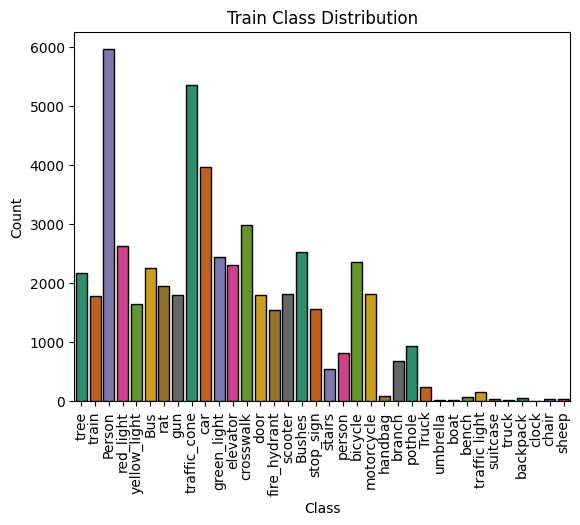

In [19]:
train_counts_by_id = count_classes_by_id(train_label_dst)
plot_class_distribution(train_counts_by_id, class_names, 'Train Class Distribution')

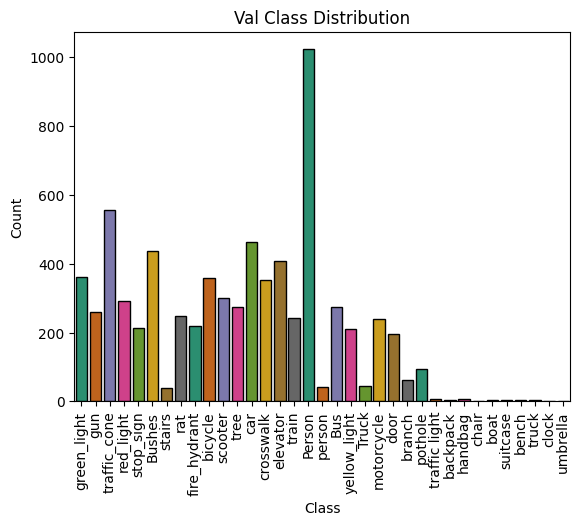

In [20]:
val_counts_by_id   = count_classes_by_id(val_label_dst)
plot_class_distribution(val_counts_by_id, class_names, 'Val Class Distribution')

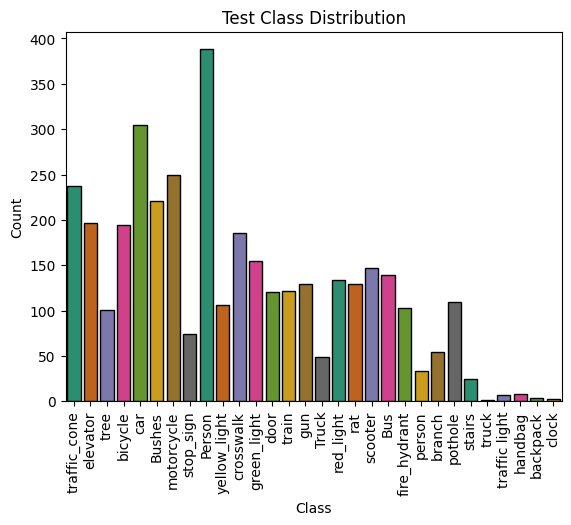

In [21]:
test_counts_by_id  = count_classes_by_id(test_label_dst)
plot_class_distribution(test_counts_by_id, class_names, 'Test Class Distribution')


### Testing Conversion

Height: 300
Width: 300
Channels: 3


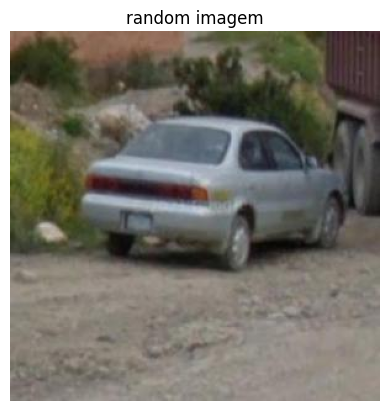

In [25]:
image = cv2.imread(base_path/'test/-0573F94C-289D-4503-A571-94C6C8C5674C-png_jpg.rf.203ce892cfb5f1007edfffc3583c559c.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
height, width, channels = image.shape
print(f'Height: {height}')
print(f'Width: {width}')
print(f'Channels: {channels}')

plt.imshow(image)
plt.title('random imagem')
plt.axis('off')
plt.show()

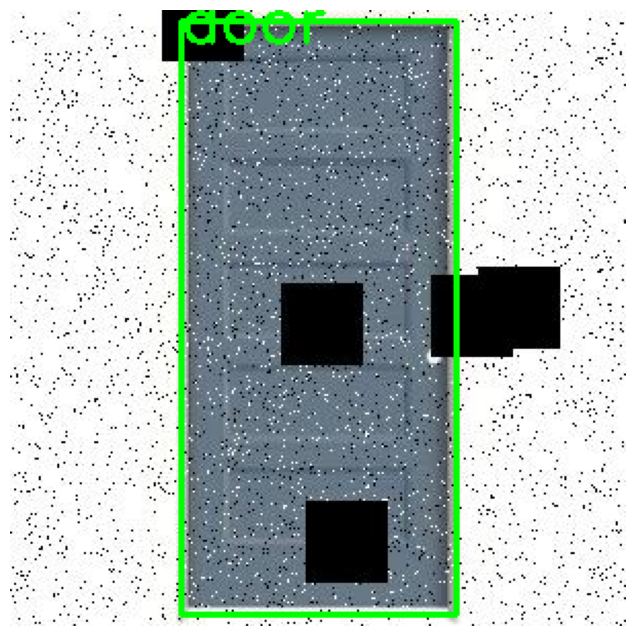

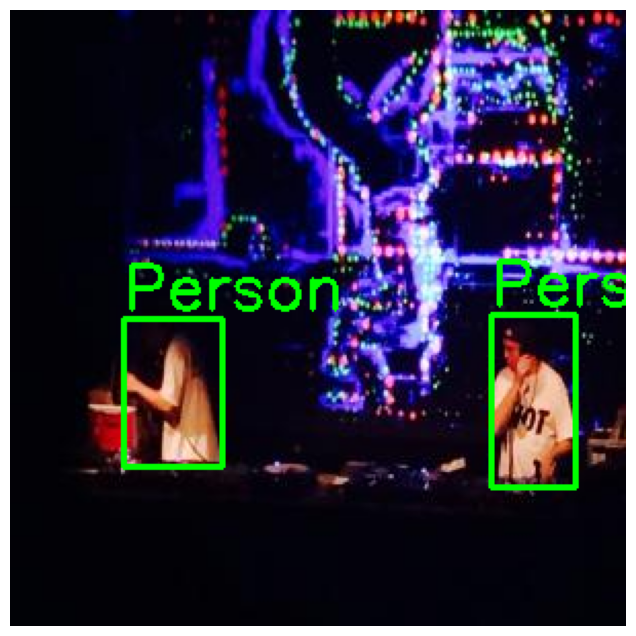

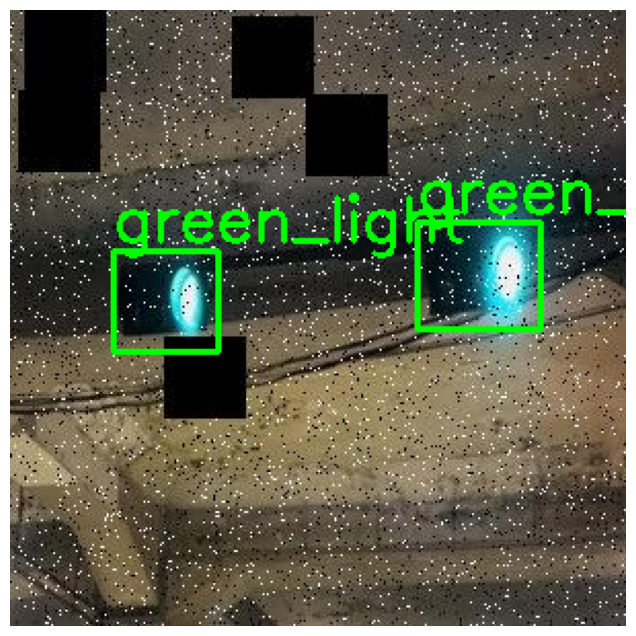

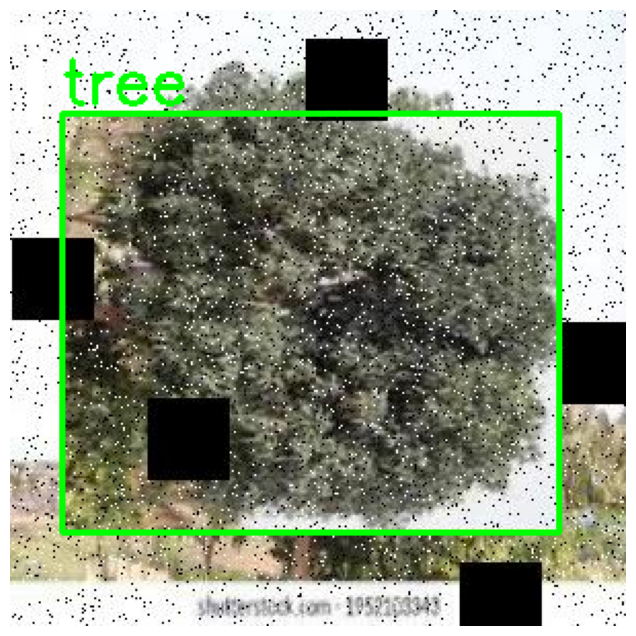

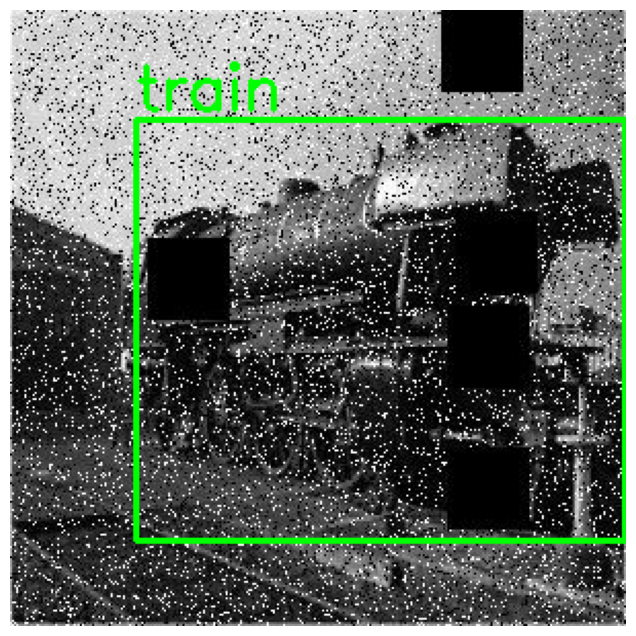

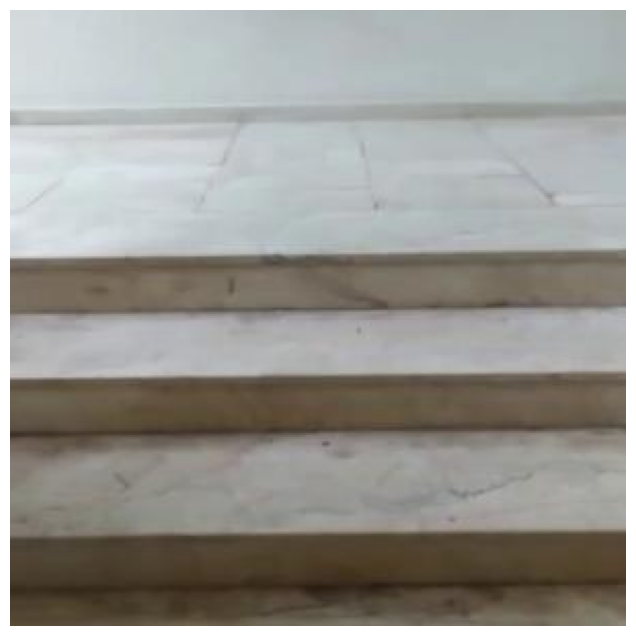

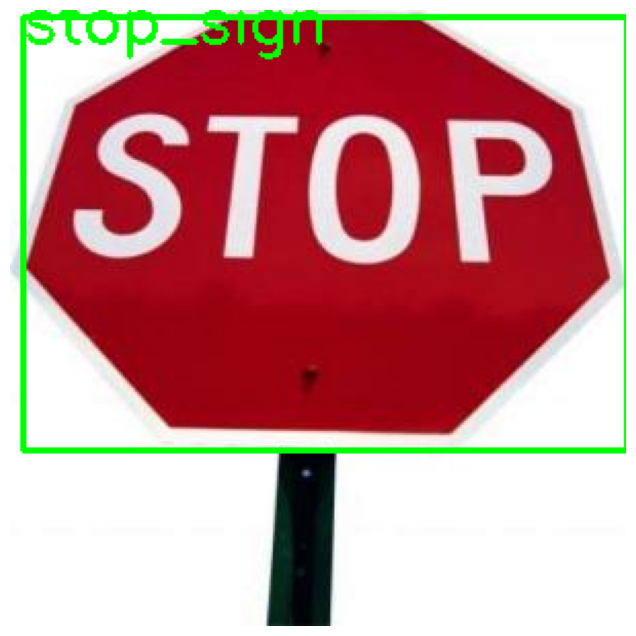

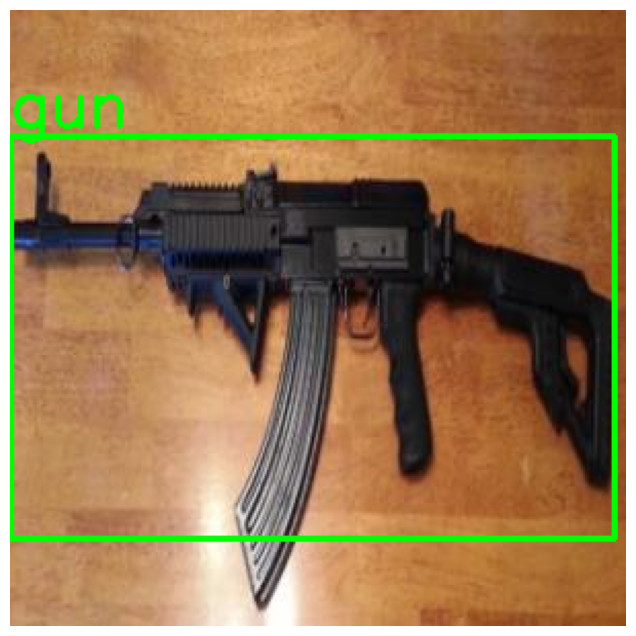

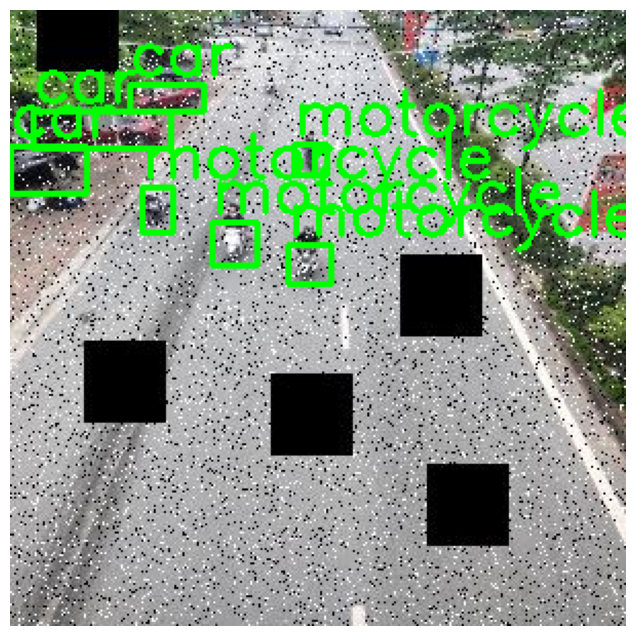

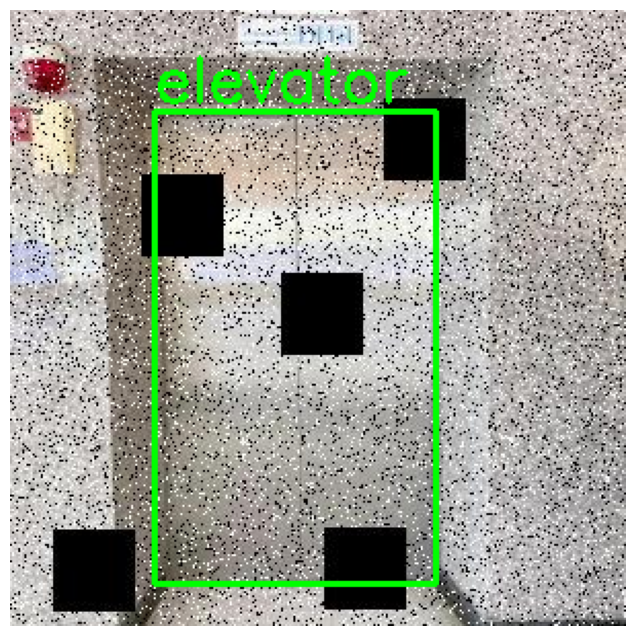

In [ ]:
all_images = sorted(os.listdir(train_image_dst))
image_files = random.sample(all_images, 10) # choose 10 images

for img_file in image_files:
    image_path = os.path.join(train_image_dst, img_file)
    label_path = os.path.join(train_label_dst, img_file.replace('.jpg', '.txt'))

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                values = line.strip().split()
                if len(values) == 5:
                    cls, x, y, bw, bh = map(float, values)

                    cls = int(cls)
                    x1 = int((x - bw / 2) * w)
                    y1 = int((y - bh / 2) * h)
                    x2 = int((x + bw / 2) * w)
                    y2 = int((y + bh / 2) * h)
                    
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(img, class_names[cls], (x1, max(15, y1 - 5)),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

- Cleaning labels

In [29]:
def clean_labels(image_dir, label_dir):
    if not os.path.exists(image_dir) or not os.path.exists(label_dir):
        print(f'Error: Directory {image_dir} or {label_dir} does not exist.')
        return
    
    image_extensions = ('.jpg', '.jpeg', '.png')
    images_files = [f for f in os.listdir(image_dir) if f.lower().endswith(image_extensions)]

    removed_files = 0
    processed_files = 0

    for image_file in tqdm(images_files, desc=f'Cleaning labels in {label_dir}'):
        base_name = os.path.splitext(image_file)[0]
        matching_labels = [f for f in os.listdir(label_dir) if f.startswith(base_name) and f.endswith('.txt')]

        if not matching_labels:
            continue

        matching_labels.sort()

        for dup_label in matching_labels[1:]:
            os.remove(os.path.join(label_dir, dup_label))
            removed_files += 1

        label_path = os.path.join(label_dir, matching_labels[0])
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
        
            seen = set()
            unique_lines = []
            for line in lines:
                line = line.strip()
                if line and line not in seen:
                    seen.add(line)
                    unique_lines.append(line + '\n')
            
            with open(label_path, 'w') as f:
                f.writelines(unique_lines)
            
            processed_files +=1
        
    print(f'Summary: Processed {processed_files} label files, removed {removed_files} duplicate label files in {label_dir}')


clean_labels(train_image_dst, train_label_dst)
clean_labels(val_image_dst, val_label_dst)
clean_labels(test_image_dst, test_label_dst)

Cleaning labels in /home/otonielnn/.cache/kagglehub/datasets/uav-edge-intelligence/labels/train: 100%|██████████| 32511/32511 [12:01<00:00, 45.09it/s]


Summary: Processed 32511 label files, removed 0 duplicate label files in /home/otonielnn/.cache/kagglehub/datasets/uav-edge-intelligence/labels/train


Cleaning labels in /home/otonielnn/.cache/kagglehub/datasets/uav-edge-intelligence/labels/val: 100%|██████████| 4246/4246 [00:11<00:00, 355.52it/s]


Summary: Processed 4246 label files, removed 0 duplicate label files in /home/otonielnn/.cache/kagglehub/datasets/uav-edge-intelligence/labels/val


Cleaning labels in /home/otonielnn/.cache/kagglehub/datasets/uav-edge-intelligence/labels/test: 100%|██████████| 2165/2165 [00:03<00:00, 655.34it/s]

Summary: Processed 2165 label files, removed 0 duplicate label files in /home/otonielnn/.cache/kagglehub/datasets/uav-edge-intelligence/labels/test
